# Solar Radiation Nowcasting — 3-Hour Dispatch Model

**Goal:** Predict solar irradiance (kW/m²) up to 3 hours ahead using 15-min weather station data from El Junco, San Cristóbal Island, Galápagos.

**Strategy:** 6 XGBoost regressors, one per 30-minute horizon. Predict the *ramp* (change in solar_kw), then reconstruct absolute values.

**Same-day guarantee:** Every training sample's 6 target horizons (T+30m through T+180m) stay within the same operational day.
We constrain training to **06:00–15:00** — the window where all 6 horizons fall within daylight (max 18:00).
This avoids useless night predictions and midnight crossovers.

**Structure:**
1. Load & clean data
2. Feature engineering (ramp mechanics, cyclical time, lag memory)
3. Filter operational window, generate targets, split
4. Train XGBoost model (6 horizon-specific regressors)
5. Save models and metadata
6. Visualization — feature importance + example forecast
7. [Appendix] Baselines: persistence & climatology

---
## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import json
from pathlib import Path

RANDOM_STATE = 42
DATA_PATH = "clean_jun_v2.csv"
OUTPUT_DIR = Path("models_final")
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
df_raw = pd.read_csv(DATA_PATH)
df_raw['TIMESTAMP'] = pd.to_datetime(df_raw['TIMESTAMP'])
df_raw = df_raw.set_index('TIMESTAMP').sort_index()
print(f"Loaded {len(df_raw):,} rows from {df_raw.index.min()} to {df_raw.index.max()}")
df_raw.head(3)

Loaded 375,325 rows from 2015-06-22 15:00:00 to 2026-03-06 06:00:00


,rain_mm,temp_c,rh_avg,rh_max,rh_min,solar_kw,net_rad_wm2,wind_speed_ms,wind_dir,soil_moisture_1,soil_moisture_2,soil_moisture_3,leaf_wetness,leaf_wet_minutes,rain_mm_is_missing
TIMESTAMP,,,,,,,,,,,,,,,
2015-06-22 15:00:00,0.0,20.97,97.839353,99.9,97.218925,0.217,191.300000,3.379000,139.500000,0.549000,0.543,0.569000,280.200000,0.0,0
2015-06-22 15:15:00,0.0,21.05,97.839353,100.0,97.218925,0.112,94.896667,3.709333,156.533333,0.549000,0.543,0.569333,291.000000,0.0,0
2015-06-22 15:30:00,0.0,20.90,97.839353,100.0,97.218925,0.085,63.973333,4.169333,138.633333,0.547333,0.543,0.569000,330.933333,0.0,0


---
## 2. Feature Engineering

All features are computed from the raw 15-min data, then resampled to 30-min resolution.

In [3]:
def engineer_features(df, resample_rule='30min'):
    """Resample 15-min station data to 30-min and create features."""
    df = df.copy()
    
    # --- Resample to 30-min means ---
    df = df.resample(resample_rule).mean()
    
    # A. Cyclical time features
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    df['doy_sin']  = np.sin(2 * np.pi * df.index.dayofyear / 365.25)
    df['doy_cos']  = np.cos(2 * np.pi * df.index.dayofyear / 365.25)

    # B. Velocity & acceleration (ramp mechanics)
    df['v_solar'] = df['solar_kw'].diff()
    df['a_solar'] = df['v_solar'].diff()
    df['solar_volatility_2h'] = df['solar_kw'].rolling(window=4).std()
    
    # C. Environmental interaction
    if 'rh_avg' in df.columns:
        df['v_humidity'] = df['rh_avg'].diff()
        df['humidity_solar_risk'] = (df['rh_avg'] / 100) * (1 - df['solar_kw'])

    # D. Lag memory (6h and 24h) for all physical sensors
    physical_sensors = ['solar_kw', 'net_rad_wm2', 'temp_c', 'rh_avg', 
                        'wind_speed_ms', 'wind_dir', 'rain_mm']
    lag_cols = [c for c in physical_sensors if c in df.columns]
    for col in lag_cols:
        df[f'{col}_lag_6h'] = df[col].shift(12)
        df[f'{col}_lag_24h'] = df[col].shift(48)
        
    # E. 30-min step-by-step history (solar only)
    for i in range(1, 7):
        df[f'solar_lag_{i*30}m'] = df['solar_kw'].shift(i)

    # F. Clear sky proxy
    df['solar_time_ratio'] = df['solar_kw'] / (df['hour_sin'] + 0.1)
    df['solar_time_ratio'] = df['solar_time_ratio'].clip(0, 5)
    
    # G. Wind vectors
    wd_rad = np.radians(df['wind_dir'])
    df['wind_x'] = df['wind_speed_ms'] * np.cos(wd_rad)
    df['wind_y'] = df['wind_speed_ms'] * np.sin(wd_rad)

    # H. Wet ground memory
    if 'leaf_wetness' in df.columns:
        df['wet_ground_lag_6h'] = df['leaf_wetness'].shift(12)

    # I. True 1-hour trend
    df['solar_trend_1h'] = df['solar_kw'] - df['solar_kw'].shift(2)

    return df.dropna()


df = engineer_features(df_raw)
print(f"After feature engineering: {df.shape[0]:,} rows, {df.shape[1]} columns")

After feature engineering: 187,615 rows, 49 columns


---
## 3. Filter & Split

**Three filters applied in order:**
1. **Operational window** (06:00–15:00) — all 6 horizons fit in daylight (max 18:00)
2. **Chronological 80/20** — proper time series split

Every training sample's target horizons are within the same day. No midnight crossovers (last prediction is at 15:00).

In [4]:
# ==========================================
# 1. OPERATIONAL WINDOW FILTER (same-day guarantee)
# ==========================================
# 06:00-15:00: all 6 horizons fit within a single daylight window (max 18:00)
OPERATIONAL_START = 6   # 06:00
OPERATIONAL_END   = 15  # 15:00 (T+180m = 18:00)

df_day  = df.between_time(f'{OPERATIONAL_START}:00', f'{OPERATIONAL_END}:00').copy()
print(f"Operational window ({OPERATIONAL_START}:00-{OPERATIONAL_END}:00): {len(df_day):,} rows")

# ==========================================
# 2. TARGET GENERATION (6 horizons, all same-day safe)
# ==========================================
steps = list(range(1, 7))
horizon_names = [f'{s*30}m' for s in steps]
target_cols = [f'target_solar_diff_{h}' for h in horizon_names]

for s in steps:
    df_day[f'target_solar_diff_{s*30}m'] = df_day['solar_kw'].shift(-s) - df_day['solar_kw']

df_day = df_day.dropna()
feature_cols = [c for c in df_day.columns if not c.startswith('target_')]
print(f"Features: {len(feature_cols)}, Targets: {len(target_cols)}")
print(f"Final dataset: {len(df_day):,} rows")

# ==========================================
# 3. CHRONOLOGICAL SPLIT (80/20)
# ==========================================
n = len(df_day)
train_end = int(n * 0.8)
train = df_day.iloc[:train_end] # 80% of data
test  = df_day.iloc[train_end:] # 20% of data

print(f"\nTrain: {len(train):,} ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test:  {len(test):,} ({test.index.min().date()} to {test.index.max().date()})")

Operational window (6:00-15:00): 74,254 rows
Features: 49, Targets: 6
Final dataset: 74,248 rows

Train: 59,398 (2015-06-23 to 2024-01-14)
Test:  14,850 (2024-01-14 to 2026-03-05)


---
## 4. Model A: General Daylight Model (Primary)

6 XGBoost regressors predicting the ramp (Δsolar) at each horizon. Trained on the 06:00–15:00 operational window (Model A).

In [5]:
xgb_params = {
    'objective': 'reg:pseudohubererror',
    'n_estimators': 350,
    'max_depth': 8,
    'learning_rate': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': 0
}

models_day = {}
for i, t in enumerate(target_cols):
    h = horizon_names[i]
    print(f"Training Model A — T+{h}...", end=' ')
    m = xgb.XGBRegressor(**xgb_params)
    m.fit(train[feature_cols], train[t])
    models_day[f"daylight_{h}"] = (m, h)
    print("OK")

print("\nAll 6 models trained.")

Training Model A — T+30m... OK
Training Model A — T+60m... OK
Training Model A — T+90m... OK
Training Model A — T+120m... OK
Training Model A — T+150m... OK
Training Model A — T+180m... OK

All 6 models trained.


In [6]:
def evaluate_models(models_dict, dataset, ds_label):
    """Evaluate a dict of (model, horizon_name) on a dataset.
    Returns results as a DataFrame."""
    rows = []
    solar_vals = dataset['solar_kw'].values
    for label, (m, h) in models_dict.items():
        target = f'target_solar_diff_{h}'
        actual_target = dataset[target].values
        pred_ramp = m.predict(dataset[feature_cols])
        pred_abs = np.clip(solar_vals + pred_ramp, 0, None)
        actual_abs = solar_vals + actual_target
        
        mask = (~np.isnan(actual_abs)) & (actual_abs > 0.01)
        if mask.sum() == 0:
            continue
        
        mae_watts = mean_absolute_error(actual_abs[mask], pred_abs[mask]) * 1000
        err = np.abs(actual_abs[mask] - pred_abs[mask])
        within_50w = (err < 0.05).mean() * 100
        
        rows.append({
            'model': label.split('_')[0],
            'horizon': h,
            'horizon_min': int(h.replace('m','')),
            'mae_wm2': round(mae_watts, 2),
            'within_50w_pct': round(within_50w, 1),
            'n_samples': int(mask.sum()),
            'set': ds_label
        })
    return pd.DataFrame(rows).sort_values('horizon_min')


eval_day = evaluate_models(models_day, test, 'test')
eval_day

,model,horizon,horizon_min,mae_wm2,within_50w_pct,n_samples,set
0,daylight,30m,30,34.47,77.4,13954,test
1,daylight,60m,60,45.93,67.7,13958,test
2,daylight,90m,90,50.17,64.3,13960,test
3,daylight,120m,120,56.62,59.2,13961,test
4,daylight,150m,150,57.95,58.4,13961,test
5,daylight,180m,180,61.78,55.2,13961,test


---
## 5. Save Models & Metadata

Models saved as XGBoost JSON. metadata.json stores feature list and evaluation results for the paper tables.

In [13]:
def save_model_set(models_dict, prefix):
    saved = []
    for label, (m, h) in models_dict.items():
        fname = f"{OUTPUT_DIR}/{prefix}_{h}.json"
        m.save_model(fname)
        saved.append(fname)
    return saved

saved_day = save_model_set(models_day, "daylight")

In [8]:
metadata = {
    'description': 'Solar nowcasting model — GalapaOS project',
    'data_source': DATA_PATH,
    'operational_window': f'{OPERATIONAL_START}:00-{OPERATIONAL_END}:00',
    'same_day_guarantee': True,
    'n_features': len(feature_cols),
    'feature_cols': feature_cols,
    'horizon_names': horizon_names,
    'target_cols': target_cols,
    'params_daylight': xgb_params,
    'n_train': len(train),
    'n_test': len(test),
    'eval_daylight': eval_day.to_dict('records')
}

with open(OUTPUT_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"Metadata saved to {OUTPUT_DIR / 'metadata.json'}")

Metadata saved to models_final\metadata.json


---
## 6. Visualization

### 6.1 Feature Importance

Aggregated importance across all 6 horizon models. The top features reveal what drives solar nowcasting at El Junco.

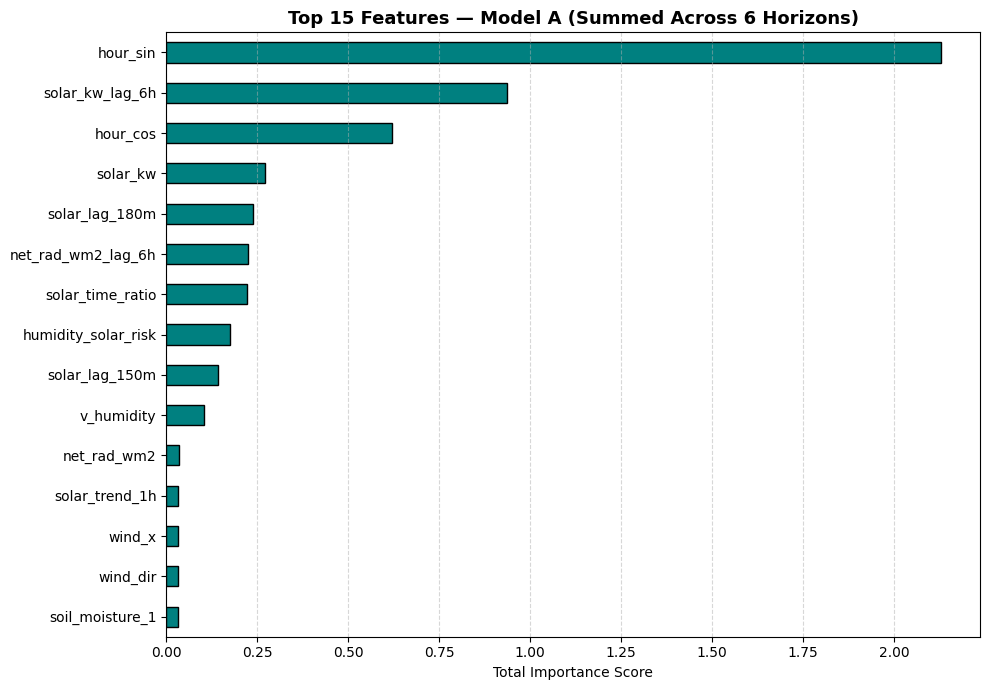

Top 10 global drivers:
hour_sin               2.129295
solar_kw_lag_6h        0.934785
hour_cos               0.621120
solar_kw               0.270429
solar_lag_180m         0.238247
net_rad_wm2_lag_6h     0.223587
solar_time_ratio       0.222410
humidity_solar_risk    0.175073
solar_lag_150m         0.141903
v_humidity             0.104669


In [9]:
# Aggregate feature importance across all 6 horizons
total_importance = pd.Series(0, index=feature_cols, dtype=float)
for label, (m, h) in models_day.items():
    total_importance += m.feature_importances_
total_importance = total_importance.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
total_importance.head(15).plot(kind='barh', color='teal', edgecolor='black', ax=ax)
ax.set_title("Top 15 Features — Model A (Summed Across 6 Horizons)", fontsize=13, fontweight='bold')
ax.set_xlabel("Total Importance Score")
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Top 10 global drivers:")
print(total_importance.head(10).to_string())

---
### 6.2 Forecast Example

3-hour dispatch forecast with MAE confidence intervals. The red fan shows Model A's expected error per horizon, and the dashed blue line is the historical climatology baseline.

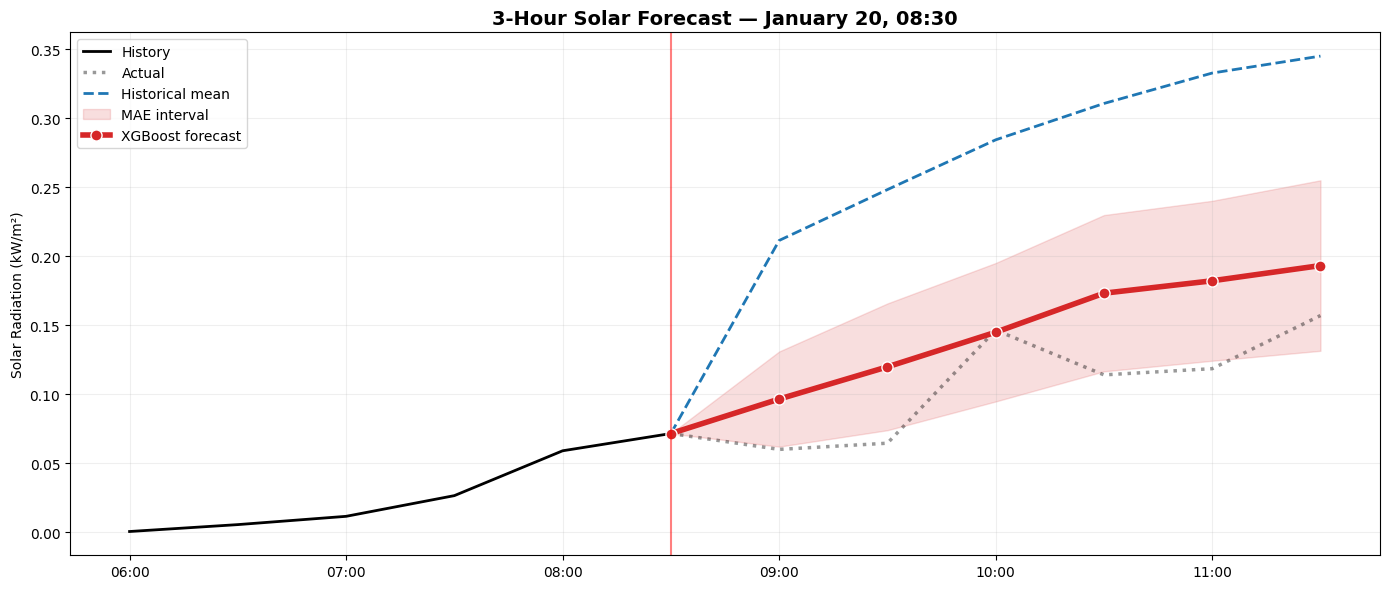

In [10]:
# Demo: plot a forecast with confidence intervals (Model A)
mae_map = eval_day.set_index('horizon')['mae_wm2'].div(1000).to_dict()

def plot_forecast(target_time_str):
    target_time = pd.Timestamp(target_time_str).floor('30min')
    if target_time not in test.index:
        print(f"{target_time} not in test set")
        return
    
    cf = test.loc[[target_time], feature_cols]
    cv = test.loc[target_time, 'solar_kw']
    
    preds_abs = []
    for h in horizon_names:
        tk = f'target_solar_diff_{h}'
        pr = models_day[f'daylight_{h}'][0].predict(cf)[0]
        preds_abs.append(np.clip(cv + pr, 0, None))
    
    mae_vals = [mae_map[h] for h in horizon_names]
    lower = [cv] + [max(0, p - m) for p, m in zip(preds_abs, mae_vals)]
    upper = [cv] + [p + m for p, m in zip(preds_abs, mae_vals)]
    
    clim = train.groupby([train.index.hour, train.index.minute])['solar_kw'].mean()
    ft = [target_time + pd.Timedelta(minutes=int(h.replace('m',''))) for h in horizon_names]
    baseline = [cv] + [clim.get((t.hour, t.minute), 0) for t in ft]
    pt = [target_time] + ft
    yp = [cv] + preds_abs
    af = [test.loc[t, 'solar_kw'] if t in test.index else np.nan for t in ft]
    ya = [cv] + af
    history = test.loc[target_time - pd.Timedelta(hours=4): target_time]
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(history.index, history['solar_kw'], 'k-', lw=2, label='History')
    ax.plot(pt, ya, 'k:', lw=2.5, alpha=0.4, label='Actual')
    ax.plot(pt, baseline, color='#1f77b4', ls='--', lw=2, label='Historical mean')
    ax.fill_between(pt, lower, upper, color='#d62728', alpha=0.15, label='MAE interval')
    ax.plot(pt, yp, color='#d62728', lw=4, marker='o', ms=8, label='XGBoost forecast', mec='white')
    ax.axvline(target_time, color='red', alpha=0.5)
    ax.set_title(f"3-Hour Solar Forecast — {target_time.strftime('%B %d, %H:%M')}", fontsize=14, fontweight='bold')
    ax.set_ylabel("Solar Radiation (kW/m²)")
    ax.legend(loc='upper left', frameon=True)
    ax.grid(True, alpha=0.2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.tight_layout()
    plt.show()

plot_forecast('2024-01-20 08:30')

---
## Appendix: Baselines

Two trivial baselines for context when reporting XGBoost performance:

- **Persistence:** `pred = current solar` for all 6 horizons. Free, no model.
- **Climatology:** historical mean solar at each time-of-day (computed from training set).

Both evaluated on the same test set for direct comparison.

In [11]:
def evaluate_persistence(dataset):
    """Persistence baseline: last known value for all horizons."""
    rows = []
    solar_vals = dataset['solar_kw'].values
    for s, h in zip(steps, horizon_names):
        target = f'target_solar_diff_{h}'
        actual_abs = solar_vals + dataset[target].values
        pred_abs = solar_vals  # persistence
        mask = (~np.isnan(actual_abs)) & (actual_abs > 0.01)
        if mask.sum() == 0:
            continue
        mae_w = mean_absolute_error(actual_abs[mask], pred_abs[mask]) * 1000
        err = np.abs(actual_abs[mask] - pred_abs[mask])
        within = (err < 0.05).mean() * 100
        rows.append({'baseline': 'persistence', 'horizon': h,
                     'horizon_min': s*30, 'mae_wm2': round(mae_w, 2),
                     'within_50w_pct': round(within, 1)})
    return pd.DataFrame(rows).sort_values('horizon_min')

def evaluate_climatology(dataset, train_set):
    """Climatology baseline: historical mean from training set."""
    clim = train_set.groupby([train_set.index.hour, train_set.index.minute])['solar_kw'].mean()
    rows = []
    solar_vals = dataset['solar_kw'].values
    for s, h in zip(steps, horizon_names):
        target = f'target_solar_diff_{h}'
        actual_abs = solar_vals + dataset[target].values
        # Map each future timestamp to its climatology value
        future_times = dataset.index + pd.Timedelta(minutes=s*30)
        clim_vals = np.array([clim.get((t.hour, t.minute), 0) for t in future_times])
        mask = (~np.isnan(actual_abs)) & (actual_abs > 0.01)
        if mask.sum() == 0:
            continue
        mae_w = mean_absolute_error(actual_abs[mask], clim_vals[mask]) * 1000
        err = np.abs(actual_abs[mask] - clim_vals[mask])
        within = (err < 0.05).mean() * 100
        rows.append({'baseline': 'climatology', 'horizon': h,
                     'horizon_min': s*30, 'mae_wm2': round(mae_w, 2),
                     'within_50w_pct': round(within, 1)})
    return pd.DataFrame(rows).sort_values('horizon_min')

eval_persist = evaluate_persistence(test)
eval_clim = evaluate_climatology(test, train)
baselines = pd.concat([eval_persist, eval_clim], ignore_index=True)
baselines

,baseline,horizon,horizon_min,mae_wm2,within_50w_pct
0,persistence,30m,30,44.70,68.4
1,persistence,60m,60,73.80,43.8
2,persistence,90m,90,99.12,28.2
3,persistence,120m,120,121.14,21.1
4,persistence,150m,150,139.07,18.8
5,persistence,180m,180,153.06,17.7
6,climatology,30m,30,80.85,42.6
7,climatology,60m,60,81.43,42.5
8,climatology,90m,90,82.82,40.8
9,climatology,120m,120,85.22,37.9


In [12]:
# Side-by-side: XGBoost vs baselines
summary = eval_day[['horizon', 'mae_wm2', 'within_50w_pct']].copy()
summary.columns = ['horizon', 'xgb_mae_wm2', 'xgb_within_50w_pct']

for df_baseline, name in [(eval_persist, 'persistence'), (eval_clim, 'climatology')]:
    summary = summary.merge(
        df_baseline[['horizon', 'mae_wm2']].rename(columns={'mae_wm2': f'{name}_mae_wm2'}),
        on='horizon'
    )

print("MAE comparison (W/m²) — lower is better")
summary

MAE comparison (W/m²) — lower is better


,horizon,xgb_mae_wm2,xgb_within_50w_pct,persistence_mae_wm2,climatology_mae_wm2
0,30m,34.47,77.4,44.70,80.85
1,60m,45.93,67.7,73.80,81.43
2,90m,50.17,64.3,99.12,82.82
3,120m,56.62,59.2,121.14,85.22
4,150m,57.95,58.4,139.07,88.99
5,180m,61.78,55.2,153.06,94.02
